Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0

# Abdominal Ultrasound Segmentation with MONAI — V1: Liver-Only Baseline

This is **Notebook V1 (Liver-Only Baseline)**. We train a 2D UNet to segment the liver in abdominal ultrasound — a focused binary segmentation task that establishes the training pipeline works cleanly before we attempt anything more ambitious.

**The companion notebook** ([`abdomen_us_v2_class_weighted.ipynb`](./abdomen_us_v2_class_weighted.ipynb)) extends this same pipeline to multi-class segmentation (8 organs) with class-weighted loss.

**Target:** Liver (binary foreground vs. background)  
**Modality:** Abdominal Ultrasound (B-mode)  
**Task:** Binary 2D segmentation  
**Dataset:** [US simulation & segmentation](https://www.kaggle.com/datasets/ignaciorlando/ussimandsegm)  
**Author:** Lakshmi Mahabaleshwara

## What this tutorial covers

1. Environment detection (Kaggle / Colab / local) and dataset access
2. Config-driven design: a single `Config` dataclass drives everything downstream
3. Manifest construction: building a pandas dataframe that is the single source of truth for splits, paths, and metadata
4. Subject-grouped train/val splits (avoiding patient leakage)
5. Decoding RGB-color-coded segmentation masks and collapsing to binary (liver vs. background)
6. A MONAI-compatible dataset and transform pipeline
7. Training a 2D UNet with mixed-precision and `DiceCELoss`
8. Evaluation reporting Dice on both synthetic and real ultrasound test sets

## Audience and prerequisites

Written for **ML practitioners new to MONAI** and **beginners learning medical segmentation**. Assumes Python fluency; explains ML concepts as they come up.

## About the data

The dataset contains two domains:
- **AUS** (Artificial US): 926 synthetic scans generated by a ray-casting simulator from CT, with annotations.
- **RUS** (Real US): 617 real scans from a SonoSite M-Turbo scanner. Only 61 real scans in the test folder have annotations.

Because labeled real-ultrasound training data does not exist in this dataset, we **train and validate on AUS (synthetic)** and **report test-set performance on both AUS and the 61 annotated RUS images**.

## 1. Environment detection

**What this section does:** Detects whether the notebook is running on Kaggle, Google Colab, or a local machine, and sets up environment-specific defaults that the rest of the notebook reads from.

**Why detect the environment?** The same notebook should run unchanged in three places, but dataset paths, package installs, and worker settings differ. Detecting once and centralizing the result is cleaner than scattering `if env == "kaggle"` checks throughout the code.

### §1.1 — Detecting which platform we're on

**What this cell does:** Checks for filesystem markers (`/kaggle/input`) and import availability (`google.colab`) to figure out where we're running. Returns one of `"kaggle"`, `"colab"`, or `"local"`.

**Why this approach instead of a config flag:** Detection is unambiguous, the markers exist, or they don't. A flag would require the user to set it correctly, which is one more thing that can go wrong.

In [1]:
import os
import sys
from pathlib import Path


def detect_environment() -> str:
    """Return one of 'kaggle', 'colab', 'local'."""
    if os.path.exists("/kaggle/input"):
        return "kaggle"
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        pass
    return "local"


ENV = detect_environment()
print(f"Detected environment: {ENV}")


Detected environment: kaggle


### §1.2 — Installing dependencies

**What this cell does:** Installs MONAI (and `kagglehub` if not on Kaggle) only if they're not already available. Also sets two environment variables to suppress harmless CUDA plugin warnings.

**Why a defensive install function?** On Kaggle, MONAI is usually pre-installed in the Docker image, so we want to skip the install. On Colab and local, we need to install it. Network failures (e.g., no internet) should produce actionable error messages, not opaque `pip` errors.

**About `TF_CPP_MIN_LOG_LEVEL` and `TF_ENABLE_ONEDNN_OPTS`:** Kaggle's Python image ships both TensorFlow and PyTorch. They each register their own cuFFT/cuDNN/cuBLAS plugins, which produces duplicate-registration warnings on import. These warnings are harmless (CUDA falls back to whichever was registered first) but visually noisy. The two env vars silence them.

**Kaggle internet note:** If you're on Kaggle and see a DNS error like "Failed to establish a new connection," your notebook doesn't have internet access enabled. Open the right-hand sidebar → "Notebook options" → toggle "Internet" ON. (Phone verification is required, free, one-time.)

In [2]:
# Note
#   1. Already installed (Kaggle usually has MONAI pre-installed) — skip
#   2. Not installed, internet available — install
#   3. Not installed, no internet — print actionable error
import importlib
import subprocess

# Suppress harmless CUDA plugin registration warnings (TF + PyTorch double-register
# on Kaggle's image). Set before any other imports.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"


def _ensure_package(pkg_name: str, pip_spec: str | None = None) -> bool:
    """Return True if importable. If not, try to install."""
    try:
        importlib.import_module(pkg_name)
        return True
    except ImportError:
        pass

    pip_spec = pip_spec or pkg_name
    print(f"{pkg_name} not found. Attempting install of {pip_spec}...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pip_spec],
        capture_output=True, text=True,
    )
    if result.returncode == 0:
        print(f"  Installed {pip_spec}")
        return True

    err = (result.stderr or "") + (result.stdout or "")
    if "name resolution" in err.lower() or "could not find a version" in err.lower():
        print(
            f"\n  Could not install {pip_spec}: no internet access.\n"
            f"  On Kaggle: open the right-hand sidebar -> 'Notebook options' -> "
            f"toggle 'Internet' ON.\n."
            f"  Then restart the kernel and re-run.\n"
        )
    else:
        print(f"  Install failed:\n{err[:1000]}")
    return False


_ensure_package("monai", "monai[all]")
if ENV != "kaggle":
    _ensure_package("kagglehub")

# Standard imports
import json
import random
import re
import warnings
from dataclasses import dataclass, field, asdict
from typing import Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import monai
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Compose, EnsureChannelFirstd, LoadImaged, Lambdad, MapTransform,
    RandAdjustContrastd, RandFlipd, RandGaussianNoised, Resized,
    ScaleIntensityd, Activationsd, AsDiscreted,
)
from monai.utils import set_determinism

warnings.filterwarnings("ignore", category=UserWarning)
print_config()


E0000 00:00:1778775775.987730     161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778775775.993754     161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778775776.012389     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778775776.012423     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778775776.012426     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778775776.012428     161 computation_placer.cc:177] computation placer already registered. Please check linka

MONAI version: 1.5.2
Numpy version: 2.4.4
Pytorch version: 2.10.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cpu
tqdm version: 4.67.3
lmdb version: 2.2.0
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: 3.12.0
pynrrd version: 1.1.3
clearml version: 2.1.7

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



## 2. Config

**What this section does:** Defines every parameter the notebook uses in one place, as a `Config` dataclass.

**Why this design?** When you fork this notebook for a different dataset (or just want to tune hyperparameters), you change *one cell* instead of hunting through 20 cells. This is the "build once, reuse many" principle made concrete.

### §2.1 — Defining the config dataclass

**What this cell does:** Creates a hierarchical `Config` object with sub-configs for `data`, `model`, and `train`. Sets random seeds for reproducibility. Detects the GPU.

**Why dataclass instead of dict?** Dataclasses give you type hints, default values, and IDE autocomplete. They also fail loudly if you typo a field name (`cfg.batch_szie` raises `AttributeError` immediately, vs. `cfg["batch_szie"]` silently returning `None`).

**Why nested sub-configs?** Logical grouping. `cfg.data.image_size` and `cfg.train.batch_size` are clearly different categories of parameter. A flat config gets confusing fast.

**The `TUTORIAL_MODE` flag:** Toggles between fast verification mode (5 epochs, 30% data, ~10 min on T4) and full training (50 epochs, full data, ~75 min). Set it `True` first to verify the pipeline works end-to-end, then flip to `False` for a real run.

**Key task-specific setting:** `out_channels = 2` — this notebook produces 2 (background + liver). Binary tasks need only 2 output channels.

**`set_determinism(seed=...)`:** MONAI's helper that seeds Python's `random`, NumPy, PyTorch, and CUDA RNGs all at once.

In [3]:
# ==== Master flag ====
TUTORIAL_MODE = False  # True = fast pass (5 epochs, 30% data); False = full training (50 epochs)


@dataclass
class DataConfig:
    """Paths and data-sampling config. Most paths are resolved at runtime."""
    data_root: Optional[Path] = None     # Resolved from ENV in §3
    aus_dir: Optional[Path] = None
    rus_dir: Optional[Path] = None
    image_size: int = 256             # Resize target for both H and W
    val_fraction: float = 0.15       # Fraction of AUS-train subjects held out for val
    tutorial_train_frac: float = 0.3
    tutorial_val_frac: float = 1.0


@dataclass
class ModelConfig:
    in_channels: int = 1                      # Grayscale US
    out_channels: int = 2                     # 2 (background + liver)
    channels: tuple = (16, 32, 64, 128, 256)  # UNet feature counts per level
    strides: tuple = (2, 2, 2, 2)
    num_res_units: int = 2


@dataclass
class TrainConfig:
    batch_size: int = 16
    num_workers: int = 2
    learning_rate: float = 1e-4
    max_epochs: int = 5 if TUTORIAL_MODE else 50
    val_interval: int = 1
    early_stop_patience: int = 1000           # Effectively disabled; let cosine schedule run
    use_amp: bool = True
    seed: int = 42


@dataclass
class Config:
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    env: str = ENV
    tutorial_mode: bool = TUTORIAL_MODE


cfg = Config()
print(f"TUTORIAL_MODE = {cfg.tutorial_mode}")
print(f"out_channels = {cfg.model.out_channels} (binary: bg + liver)")
print(f"max_epochs = {cfg.train.max_epochs}, batch_size = {cfg.train.batch_size}")

set_determinism(seed=cfg.train.seed)
random.seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


TUTORIAL_MODE = False
out_channels = 2 (binary: bg + liver)
max_epochs = 50, batch_size = 16
Device: cpu


## 3. Dataset access

**What this section does:** Finds the dataset on disk, with three fallback strategies.

### §3.1 — Resolving the dataset path

**What this cell does:** Checks three locations in order — Kaggle mount, environment variable, conventional local path — and falls back to downloading via `kagglehub` if none exist.

**Why three fallbacks?** Different users will have the data in different places. The Kaggle mount is automatic if you've attached the dataset. The env var lets users with custom setups override paths. The local path matches a common convention. The kagglehub download is a last resort that requires Kaggle API credentials.

**Why a function returning `Path`?** Single point of truth. Every downstream cell asks `cfg.data.data_root` and gets the answer, regardless of which fallback succeeded. Adding a fourth fallback (e.g., S3) means changing one function, not 20 cells.

In [4]:
def _looks_like_data_root(path: Path) -> bool:
    """True if the path is the directory containing AUS/ and RUS/ subfolders."""
    return path.exists() and (path / "AUS").exists() and (path / "RUS").exists()


def resolve_data_root(env: str) -> Path:
    """Find the dataset root with three fallback strategies."""
    candidates: list[Path] = []

    if env == "kaggle":
        candidates += [
            Path("/kaggle/input/abdominal_US/abdominal_US"),
            Path("/kaggle/input/ussimandsegm/abdominal_US/abdominal_US"),
        ]

    env_path = os.environ.get("ABDOMEN_US_ROOT")
    if env_path:
        candidates.append(Path(env_path))

    candidates += [
        Path("./data/abdominal_US/abdominal_US"),
        Path("./abdominal_US/abdominal_US"),
    ]

    for c in candidates:
        if _looks_like_data_root(c):
            print(f"Found dataset locally at: {c}")
            return c

    print("Dataset not found locally. Attempting kagglehub download...")
    try:
        import kagglehub
    except ImportError as e:
        raise RuntimeError(
            "kagglehub not installed and dataset not found locally. "
            "Either install kagglehub, set ABDOMEN_US_ROOT to your local copy, "
            "or on Kaggle attach the dataset via 'Add Data'."
        ) from e

    downloaded = Path(kagglehub.dataset_download("ignaciorlando/ussimandsegm"))
    for inner in downloaded.rglob("abdominal_US"):
        if _looks_like_data_root(inner):
            print(f"Downloaded to: {inner}")
            return inner
    raise FileNotFoundError(f"Could not locate 'abdominal_US/' inside {downloaded}")


cfg.data.data_root = resolve_data_root(cfg.env)
cfg.data.aus_dir = cfg.data.data_root / "AUS"
cfg.data.rus_dir = cfg.data.data_root / "RUS"

print(f"Data root: {cfg.data.data_root}")
for sub in ["AUS/images/train", "AUS/annotations/train", "AUS/images/test",
            "AUS/annotations/test", "RUS/images/test", "RUS/annotations/test"]:
    p = cfg.data.data_root / sub
    n = len(list(p.iterdir())) if p.exists() else 0
    print(f"  {sub:<30s} {n:>5d} files")


Dataset not found locally. Attempting kagglehub download...
Downloaded to: /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US
Data root: /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US
  AUS/images/train                 633 files
  AUS/annotations/train            633 files
  AUS/images/test                  293 files
  AUS/annotations/test             293 files
  RUS/images/test                  213 files
  RUS/annotations/test              61 files


## 4. Manifest construction

**What this section does:** Walks the dataset directory and builds a pandas DataFrame that's the single source of truth for every downstream decision (splits, paths, metadata).

**Why a manifest at all?** Real medical imaging projects have dozens of decisions to make about data — which subjects to use, which scans to exclude, how to handle missing labels. Encoding these decisions as code that operates on a tabular manifest is more maintainable than encoding them as hardcoded paths or scattered conditionals. The manifest is also a reproducibility artifact — saving it to disk means anyone re-running the notebook gets the same splits.

### §4.1 — Building the manifest

**What this cell does:** Walks both `AUS/` and `RUS/` directory trees, parses subject IDs from filenames using regex, and builds a DataFrame with one row per image-mask pair.

**Why regex for subject parsing?** AUS filenames look like `ct4-63.png` (subject `ct4`, frame `63`). RUS filenames look like `a42.jpg` (subject `a`). The regex captures the subject prefix, which we'll use later for subject-grouped splits.

**Why iterate the directory once?** Walking 2,000 files on Kaggle's mounted input takes ~5 seconds. We walk once, build the manifest, and save to CSV as a reproducibility artifact. The CSV is for inspection and reproducibility, not as a runtime cache — for larger datasets you'd add `if manifest_path.exists(): return pd.read_csv(manifest_path)`.

In [5]:
AUS_FILENAME_RE = re.compile(r"^(ct\d+)-\d+\.(png|jpg)$")
RUS_FILENAME_RE = re.compile(r"^([a-z]+)\d+\.(png|jpg)$", re.IGNORECASE)


def parse_subject_id(filename: str, modality: str) -> Optional[str]:
    pattern = AUS_FILENAME_RE if modality == "AUS" else RUS_FILENAME_RE
    match = pattern.match(filename)
    return match.group(1).lower() if match else None


def build_manifest(data_root: Path) -> pd.DataFrame:
    rows = []
    for modality in ["AUS", "RUS"]:
        mod_dir = data_root / modality
        for orig_split in ["train", "test"]:
            img_dir = mod_dir / "images" / orig_split
            msk_dir = mod_dir / "annotations" / orig_split
            if not img_dir.exists():
                continue
            for img_path in sorted(img_dir.iterdir()):
                if img_path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                subject_id = parse_subject_id(img_path.name, modality)
                mask_path = msk_dir / (img_path.stem + ".png")
                rows.append({
                    "subject_id": subject_id,
                    "modality": modality,
                    "orig_split": orig_split,
                    "image_path": str(img_path),
                    "mask_path": str(mask_path) if mask_path.exists() else None,
                    "has_mask": mask_path.exists(),
                })
    return pd.DataFrame(rows)


manifest = build_manifest(cfg.data.data_root)
print(f"Total rows: {len(manifest)}")
print("\nCounts by modality x orig_split x has_mask:")
print(manifest.groupby(["modality", "orig_split", "has_mask"]).size().unstack(fill_value=0))


Total rows: 1543

Counts by modality x orig_split x has_mask:
has_mask             False  True 
modality orig_split              
AUS      test            0    293
         train           0    633
RUS      test          153     60
         train         404      0


### §4.2 — Inspecting the manifest

**What this cell does:** Prints sample rows from each modality and flags any rows where subject ID parsing failed.

**Why print samples?** Sanity check. If your regex is wrong, this is where you'd notice — sample rows would show `subject_id=None` or unexpected values. Catching it here saves debugging confusion later.

In [6]:
print("AUS sample:")
print(manifest[manifest["modality"] == "AUS"].head(3).to_string(index=False))
print("\nRUS sample:")
print(manifest[manifest["modality"] == "RUS"].head(3).to_string(index=False))

unparsed = manifest[manifest["subject_id"].isna()]
print(f"\nRows with unparsable subject_id: {len(unparsed)}")

AUS sample:
subject_id modality orig_split                                                                                               image_path                                                                                                     mask_path  has_mask
      ct14      AUS      train  /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/images/train/ct14-1.png  /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/annotations/train/ct14-1.png      True
      ct14      AUS      train /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/images/train/ct14-10.png /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/annotations/train/ct14-10.png      True
      ct14      AUS      train /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/images/train/ct14-11.png /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/anno

## 5. Subject-grouped splits

**What this section does:** Assigns each manifest row to one of `train`, `val`, `test_aus`, `test_rus`, ensuring no subject's frames appear in multiple splits.

**Why subject-grouped splits matter (the most important rule in medical ML):** If you split frames randomly, frames from the same patient end up in both train and test. The model "memorizes" patient-specific features and reports inflated test scores that don't generalize to new patients. Always split by subject.

### §5.1 — Assigning splits

**What this cell does:** Uses sklearn's `GroupShuffleSplit` with `groups=subject_id` to ensure no AUS subject appears in both train and val. Test splits are taken directly from the dataset's pre-shipped train/test directories.

**Why the assertion at the end?** Defensive programming. If our split logic ever broke, the assertion would crash loudly instead of silently producing leaky splits.

**The four splits:**
- `train`: AUS train minus held-out subjects (what we train on)
- `val`: AUS train held-out subjects (what we tune on)
- `test_aus`: AUS test (in-distribution test — how well did we learn the synthetic task?)
- `test_rus`: RUS test with masks (out-of-distribution test — how does it transfer to real ultrasound?)

Note: If you get an exception as "ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)" while running the below cell. Restart the kernel and run all cells from the beginning.

In [7]:
from sklearn.model_selection import GroupShuffleSplit


def assign_splits(manifest: pd.DataFrame, val_fraction: float, seed: int) -> pd.DataFrame:
    manifest = manifest.copy()
    manifest["split"] = None

    rus_test_mask = (manifest["modality"] == "RUS") & \
                    (manifest["orig_split"] == "test") & \
                    (manifest["has_mask"])
    manifest.loc[rus_test_mask, "split"] = "test_rus"

    aus_test_mask = (manifest["modality"] == "AUS") & (manifest["orig_split"] == "test")
    manifest.loc[aus_test_mask, "split"] = "test_aus"

    aus_train = manifest[(manifest["modality"] == "AUS") & (manifest["orig_split"] == "train")]
    groups = aus_train["subject_id"].values

    gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    train_idx, val_idx = next(gss.split(X=aus_train, y=None, groups=groups))
    train_subjects = set(aus_train.iloc[train_idx]["subject_id"].unique())
    val_subjects = set(aus_train.iloc[val_idx]["subject_id"].unique())

    manifest.loc[aus_train.index[aus_train["subject_id"].isin(train_subjects)],
                 "split"] = "train"
    manifest.loc[aus_train.index[aus_train["subject_id"].isin(val_subjects)],
                 "split"] = "val"

    # Subject-leakage assertion: catches bugs that would invalidate results
    assert train_subjects.isdisjoint(val_subjects), "Subject leak between train and val!"
    return manifest


manifest = assign_splits(manifest, cfg.data.val_fraction, cfg.train.seed)

print("Split sizes:")
print(manifest["split"].value_counts(dropna=False))
print("\nSubjects per split (non-null splits):")
print(manifest.dropna(subset=["split"]).groupby("split")["subject_id"].nunique())

manifest_path = Path("/kaggle/working/manifest.csv") if cfg.env == "kaggle" else Path("manifest.csv")
manifest.to_csv(manifest_path, index=False)
print(f"\nManifest saved: {manifest_path}")


Split sizes:
split
None        557
train       511
test_aus    293
val         122
test_rus     60
Name: count, dtype: int64

Subjects per split (non-null splits):
split
test_aus    4
test_rus    4
train       7
val         2
Name: subject_id, dtype: int64

Manifest saved: /kaggle/working/manifest.csv


### §5.2 — Optional subset for tutorial mode

**What this cell does:** When `TUTORIAL_MODE=True`, downsamples the train split to 30% to keep epochs short. Val and test are left intact.

In [8]:
if cfg.tutorial_mode:
    train_rows = manifest[manifest["split"] == "train"]
    n_keep = max(1, int(len(train_rows) * cfg.data.tutorial_train_frac))
    train_keep = train_rows.sample(n=n_keep, random_state=cfg.train.seed).index
    train_drop = train_rows.index.difference(train_keep)
    manifest.loc[train_drop, "split"] = None
    print(f"TUTORIAL_MODE: kept {n_keep}/{len(train_rows)} training frames.")


## 6. Mask decoding — liver-only binary

**What this section does:** Converts RGB color masks into binary class index maps where `1 = liver` and `0 = everything else (background, other organs, or boundary).

**Why binary for this notebook?** The dataset's masks encode 8 organ classes by color, but for this notebook we want a clean, focused binary task. If liver Dice doesn't reach a reasonable value (~0.80), we know the pipeline itself has issues, not the task.

**Why is the liver color violet (100, 0, 100)?** This is the dataset's choice. All other organs are treated as background for this notebook's purposes.

### §6.1 — Liver detection from RGB masks

**What this cell does:** Defines a function `rgb_mask_to_liver_binary` that takes an RGB mask and produces a binary class map: 1 where the pixel is closest to the liver color (violet), 0 everywhere else.

**Why nearest-neighbor matching, not exact equality?** PNG masks should have exact colors, but resize interpolation can introduce off-palette intermediate values at boundaries. Using Euclidean distance to the liver color makes this robust.

**The `int32` cast** is critical: squared RGB differences can exceed int16 range (max squared distance ≈ 195,000, int16 max = 32,767). int16 would silently overflow and corrupt pixel assignments.

In [9]:
# Color palette (full reference — V2 uses all 9 classes)
CLASS_PALETTE = [
    ((0,   0,   0),   "background"),
    ((100, 0,   100), "liver"),
    ((255, 255, 255), "bone"),
    ((0,   255, 0),   "gallbladder"),
    ((255, 255, 0),   "kidney"),
    ((0,   0,   255), "pancreas"),
    ((255, 0,   0),   "vessels"),
    ((255, 0,   255), "spleen"),
    ((0,   255, 255), "adrenal"),
]
LIVER_RGB = np.array([100, 0, 100], dtype=np.int32)
PALETTE_ARR = np.array([rgb for rgb, _ in CLASS_PALETTE], dtype=np.int32)
NUM_CLASSES = 2  # V1: binary (0 = background, 1 = liver)
CLASS_NAMES = ["background", "liver"]


def rgb_mask_to_liver_binary(mask_rgb: np.ndarray) -> np.ndarray:
    """Convert (H, W, 3) RGB mask to (H, W) binary map: 1 where pixel is liver, else 0.

    Uses nearest-neighbor matching against the full 9-color palette, then
    keeps only pixels assigned to class index 1 (liver). This handles boundary
    pixels degraded by resize interpolation more reliably than exact match
    against the liver color alone.
    """
    if mask_rgb.ndim == 2:
        return mask_rgb.astype(np.uint8)
    if mask_rgb.shape[-1] == 4:
        mask_rgb = mask_rgb[..., :3]
    h, w = mask_rgb.shape[:2]
    flat = mask_rgb.reshape(-1, 3).astype(np.int32)
    d2 = ((flat[:, None, :] - PALETTE_ARR[None, :, :]) ** 2).sum(-1)
    nearest_class = d2.argmin(axis=1).astype(np.uint8)
    binary = (nearest_class == 1).astype(np.uint8)
    return binary.reshape(h, w)


### §6.2 — Visualizing one mask decoding

**What this cell does:** Picks a training sample, shows the original ultrasound, the RGB mask, and the binary liver map side by side.

**Why this matters:** Sanity check that the decoder works. If the binary map doesn't match where the liver appears in the RGB mask, something is wrong with the decoder. 

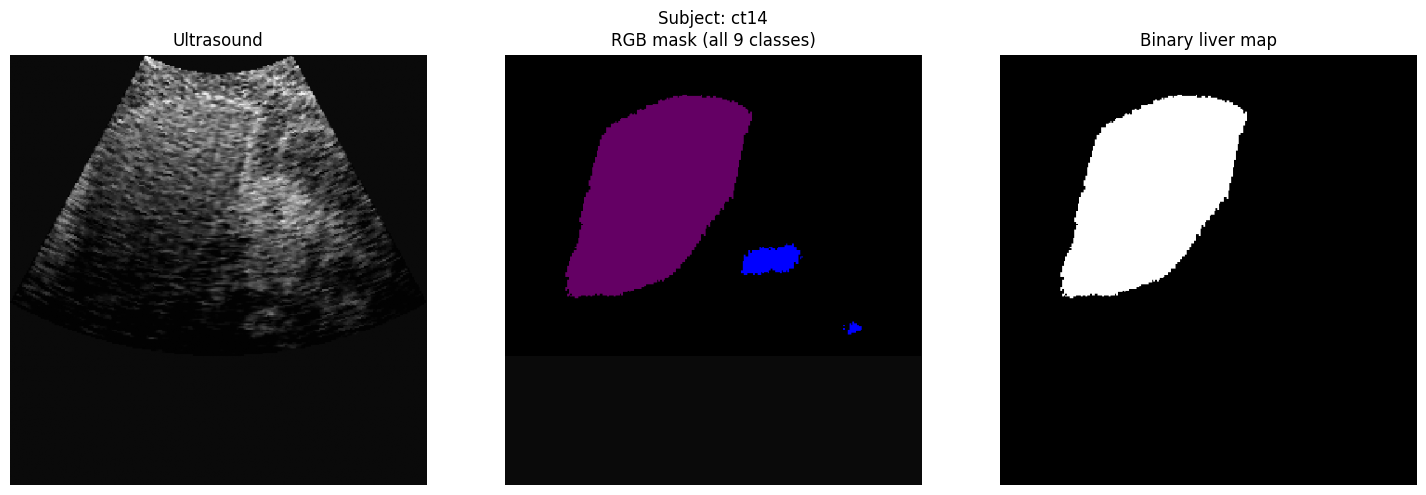


Liver pixels: 28,751 / 208,336 (13.8%)


In [10]:
sample_row = manifest[manifest["split"] == "train"].iloc[0]
img = np.array(Image.open(sample_row["image_path"]).convert("L"))
mask_rgb = np.array(Image.open(sample_row["mask_path"]).convert("RGB"))
binary_map = rgb_mask_to_liver_binary(mask_rgb)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray");      axes[0].set_title("Ultrasound"); axes[0].axis("off")
axes[1].imshow(mask_rgb);              axes[1].set_title("RGB mask (all 9 classes)"); axes[1].axis("off")
axes[2].imshow(binary_map, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Binary liver map"); axes[2].axis("off")
plt.suptitle(f"Subject: {sample_row['subject_id']}")
plt.tight_layout(); plt.show()

n_liver = int(binary_map.sum())
n_total = int(binary_map.size)
print(f"\nLiver pixels: {n_liver:,} / {n_total:,} ({100*n_liver/n_total:.1f}%)")


## 7. MONAI transforms and CacheDataset

**What this section does:** Wraps the mask decoder in a MONAI transform, defines train/val transform pipelines, and builds `CacheDataset` instances.

**Why MONAI's dictionary transforms?** They guarantee that image and mask transformations stay in sync. When `RandFlipd` flips, it flips both; when `Resized` resizes, it resizes both consistently.

### §7.1 — Custom transform: decoding masks in the pipeline

**What this cell does:** Wraps the `rgb_mask_to_liver_binary` function in a MONAI `MapTransform` so it integrates with the dictionary pipeline.

**Why a custom MapTransform instead of preprocessing masks ahead of time?** Two reasons. First, this keeps preprocessing colocated with training — no separate "preprocess masks" script that needs to stay in sync. Second, MONAI's `CacheDataset` will run this once per sample on first epoch and cache the output, so we pay no per-epoch cost.

In [11]:
class DecodeMaskd(MapTransform):
    """Decode an RGB mask into a binary liver map in a MONAI dict pipeline.

    Expects the mask to arrive as (3, H, W) or (H, W, 3) uint8. Outputs
    (1, H, W) int64 binary values (0 or 1).
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            arr = d[key]
            if hasattr(arr, "numpy"):
                arr = arr.numpy()
            arr = np.asarray(arr)
            if arr.ndim == 3 and arr.shape[0] in (3, 4):
                arr = np.transpose(arr, (1, 2, 0))
            elif arr.ndim == 3 and arr.shape[0] == 1:
                d[key] = arr.astype(np.int64)
                continue
            elif arr.ndim == 2:
                d[key] = arr[None, ...].astype(np.int64)
                continue
            decoded = rgb_mask_to_liver_binary(arr.astype(np.uint8))
            d[key] = decoded[None, ...].astype(np.int64)
        return d


### §7.2 — Building the transform pipelines

**What this cell does:** Defines two `Compose` pipelines — one for training (with augmentation) and one for validation (deterministic).

**Why these specific augmentations:**

- **`RandFlipd` horizontal only.** Abdominal ultrasound has anatomical laterality (liver right, spleen left). Vertical flip would create unphysical images.
- **`RandGaussianNoised` with small sigma (0.02).** Ultrasound is already noisy; heavy noise augmentation hurts more than helps.
- **`RandAdjustContrastd`.** Real ultrasound gain settings vary by operator; this simulates that variation.
- **No rotation.** Ultrasound images are oriented by convention.

**Why no augmentation for validation?** Deterministic metrics, comparable across epochs.

### §7.3 — CacheDataset and DataLoader

**What this cell does:** Converts manifest rows into MONAI's expected list-of-dicts format, then wraps them in `CacheDataset` for fast repeated access.

**Why CacheDataset instead of plain Dataset?** Preprocessing (load + decode + resize) takes ~20ms per sample. Across 50 epochs that's hours of pure preprocessing. `CacheDataset` runs preprocessing once at startup, caches results in RAM, and replays them every epoch.

**Why not `PersistentDataset` (disk cache)?** The dataset fits in T4 RAM after preprocessing (~1 GB). RAM is faster than disk and we don't need cache survival across kernel restarts for a tutorial.

**Why `cache_num=min(len, 500)`?** Caps the cache to the first 500 samples in case the dataset is huge. For our scale, this is `len(train_files)`.

In [12]:
def build_transforms(image_size: int, training: bool) -> Compose:
    base = [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Lambdad(keys="image",
                func=lambda x: x.mean(dim=0, keepdim=True) if x.shape[0] == 3 else x),
        DecodeMaskd(keys=["label"]),
        Resized(keys=["image"], spatial_size=(image_size, image_size), mode="bilinear"),
        Resized(keys=["label"], spatial_size=(image_size, image_size), mode="nearest"),
        ScaleIntensityd(keys="image", minv=0.0, maxv=1.0),
    ]
    if training:
        base += [
            RandFlipd(keys=["image", "label"], spatial_axis=1, prob=0.5),
            RandGaussianNoised(keys="image", prob=0.3, mean=0.0, std=0.02),
            RandAdjustContrastd(keys="image", prob=0.3, gamma=(0.8, 1.2)),
        ]
    return Compose(base)


train_transforms = build_transforms(cfg.data.image_size, training=True)
val_transforms = build_transforms(cfg.data.image_size, training=False)

In [13]:
def rows_to_monai_dicts(rows: pd.DataFrame) -> list[dict]:
    return [
        {"image": r["image_path"], "label": r["mask_path"]}
        for _, r in rows.iterrows()
        if r["mask_path"] is not None
    ]


train_files    = rows_to_monai_dicts(manifest[manifest["split"] == "train"])
val_files      = rows_to_monai_dicts(manifest[manifest["split"] == "val"])
test_aus_files = rows_to_monai_dicts(manifest[manifest["split"] == "test_aus"])
test_rus_files = rows_to_monai_dicts(manifest[manifest["split"] == "test_rus"])

print(f"train: {len(train_files)}  val: {len(val_files)}  "
      f"test_aus: {len(test_aus_files)}  test_rus: {len(test_rus_files)}")

cache_num_train = min(len(train_files), 500)
cache_num_val = min(len(val_files), 200)

train_ds = CacheDataset(data=train_files, transform=train_transforms,
                        cache_num=cache_num_train, num_workers=cfg.train.num_workers)
val_ds = CacheDataset(data=val_files, transform=val_transforms,
                      cache_num=cache_num_val, num_workers=cfg.train.num_workers)

train_loader = DataLoader(train_ds, batch_size=cfg.train.batch_size, shuffle=True,
                          num_workers=cfg.train.num_workers,
                          pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                        num_workers=cfg.train.num_workers,
                        pin_memory=(device.type == "cuda"))

print(f"Cached {cache_num_train} train samples and {cache_num_val} val samples.")


train: 511  val: 122  test_aus: 293  test_rus: 60


Loading dataset: 100%|██████████| 122/122 [00:07<00:00, 16.39it/s]

Cached 500 train samples and 122 val samples.


### §7.4 — Sanity-check a training batch

**What this cell does:** Pulls one batch from `train_loader`, prints its shapes, and visualizes the augmented images alongside their masks.

**Why this is critical:** Confirms three things at once: data shapes are correct, augmentations are being applied, and image-mask pairs stay aligned through augmentation.

Image batch: shape=(16, 1, 256, 256), dtype=torch.float32, range=[-0.06, 1.04]
Label batch: shape=(16, 1, 256, 256), dtype=torch.float32, unique classes=[0.0, 1.0]


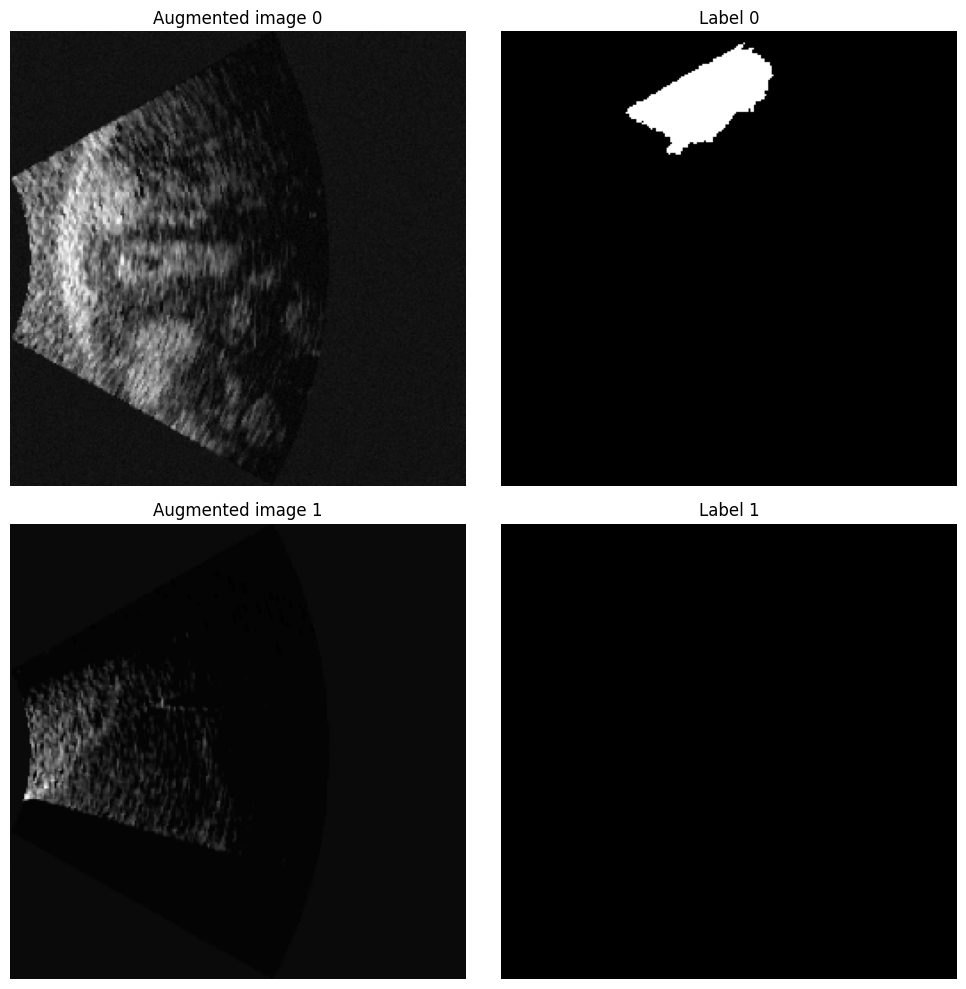

In [14]:
batch = next(iter(train_loader))
img_batch = batch["image"]
lbl_batch = batch["label"]
print(f"Image batch: shape={tuple(img_batch.shape)}, dtype={img_batch.dtype}, "
      f"range=[{img_batch.min():.2f}, {img_batch.max():.2f}]")
print(f"Label batch: shape={tuple(lbl_batch.shape)}, dtype={lbl_batch.dtype}, "
      f"unique classes={sorted(torch.unique(lbl_batch).tolist())}")

n_show = min(2, img_batch.shape[0])
fig, axes = plt.subplots(n_show, 2, figsize=(10, 5 * n_show))
if n_show == 1:
    axes = axes[None, :]
for i in range(n_show):
    axes[i, 0].imshow(img_batch[i, 0].cpu(), cmap="gray")
    axes[i, 0].set_title(f"Augmented image {i}"); axes[i, 0].axis("off")
    axes[i, 1].imshow(lbl_batch[i, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title(f"Label {i}"); axes[i, 1].axis("off")
plt.tight_layout(); plt.show()


## 8. Model, loss, optimizer

**What this section does:** Defines the three pieces that make training possible: the neural network, the loss function, and the optimizer.

### §8.1 The model — MONAI's 2D UNet

UNet is the reference architecture for medical image segmentation. The "U" shape comes from:

- **Encoder (down-path):** progressively reduces spatial resolution (256 → 128 → 64 → 32 → 16) while increasing feature channels (16 → 32 → 64 → 128 → 256). Each step captures more abstract, larger-context features.
- **Decoder (up-path):** progressively restores spatial resolution back to 256×256, producing one prediction per pixel.
- **Skip connections (the trick):** at each level, encoder features are concatenated with decoder features. Combines "where" (high-res) with "what" (abstract).

**Our specific settings:**
- `channels=(16, 32, 64, 128, 256)` — feature counts at each level
- `strides=(2, 2, 2, 2)` — downsample by 2× at each transition
- `num_res_units=2` — residual blocks at each level
- `in_channels=1, out_channels=2` — grayscale input, binary output

This gives ~2M parameters — a deliberately modest model for a T4 GPU.

### §8.2 The loss — `DiceCELoss` (plain, no weights needed for binary)

We use a **combined loss** adding Dice loss (region overlap) + Cross-Entropy loss (per-pixel classification).

**Why combine them?**
- Dice loss alone is unstable early in training when predictions are mostly empty.
- Cross-entropy alone encourages the model to predict "everything is background."
- Together: CE provides stable early learning; Dice pushes toward good overlap.

**Why no class weights here?** Binary segmentation with a single foreground class doesn't have a class-imbalance problem in the same way multi-class does. The foreground/background ratio is roughly 1:10 — manageable without explicit weighting. (Multi class segmentation notebook will demonstrate why multi-class needs weights.)

**Loss arguments:**
- `to_onehot_y=True` — labels arrive as integer `{0,1}` maps; loss converts to one-hot.
- `softmax=True` — apply softmax inside the loss for numerical stability.
- `include_background=True` — include background in the loss so the model learns to predict it.

In [15]:
model = UNet(
    spatial_dims=2,
    in_channels=cfg.model.in_channels,
    out_channels=cfg.model.out_channels,
    channels=cfg.model.channels,
    strides=cfg.model.strides,
    num_res_units=cfg.model.num_res_units,
    norm="batch",
).to(device)

# V1: foreground-focused DiceCELoss. include_background=False is the key choice
# for binary tasks — it prevents the loss from being dominated by the ~85% of
# pixels that are background, which would cause the model to overpredict liver.
loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False,
)

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train.learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.max_epochs)

# Metric: Dice on the foreground (liver) only.
# include_background=False because background is ~90% of pixels and would inflate the score.
dice_metric = DiceMetric(include_background=False, reduction="mean_batch")

post_pred = Compose([Activationsd(keys="pred", softmax=True),
                     AsDiscreted(keys="pred", argmax=True, to_onehot=cfg.model.out_channels)])
post_label = Compose([AsDiscreted(keys="label", to_onehot=cfg.model.out_channels)])

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: MONAI 2D UNet ({n_params:,} parameters)")
print(f"Loss: DiceCELoss (binary segmentation, include_background=False)")
print(f"Metric: DiceMetric (foreground only, i.e., liver)")


Model: MONAI 2D UNet (1,627,597 parameters)
Loss: DiceCELoss (binary segmentation, include_background=False)
Metric: DiceMetric (foreground only, i.e., liver)


### §8.3 The optimizer — Adam + Cosine annealing

**Adam** is an adaptive learning-rate optimizer. Robust default for medical imaging because it handles noisy gradients well. LR `1e-4` is standard for Adam with UNet.

**Cosine annealing scheduler** smoothly decreases the learning rate from `1e-4` to near-zero following a half-cosine curve. Higher LR early helps exploration; lower LR late helps convergence.

### §8.4 The metric — `DiceMetric` (different from Dice loss!)

**Important distinction:**
- The Dice *inside the loss* uses continuous probabilities (post-softmax) for differentiability.
- The Dice *as an evaluation metric* uses discrete class predictions (post-argmax) — what humans interpret as "segmentation quality."

These produce different numbers. The metric is what we report.

## 9. Training loop

**What this section does:** Runs the standard training loop with mixed precision, periodic validation, checkpointing on best validation Dice, and per-epoch metric logging.

### §9.1 — The training loop

**What this cell does:** For each epoch, trains over the train loader, validates over the val loader, logs metrics, saves checkpoints when val Dice improves.

**Why mixed precision (`torch.amp`)?** On a T4, mixed precision roughly halves training time.

**Why log metrics to a CSV every epoch?** If the kernel dies mid-training, you don't lose the run history. The `*` in epoch output marks epochs where the checkpoint was saved.

In [16]:
from torch.amp import autocast, GradScaler

history = []
best_mean_dice = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_path = (Path("/kaggle/working") if cfg.env == "kaggle" else Path(".")) / "best_model.pth"
history_path = (Path("/kaggle/working") if cfg.env == "kaggle" else Path(".")) / "train_history.csv"

scaler = GradScaler("cuda", enabled=cfg.train.use_amp and device.type == "cuda")

for epoch in range(1, cfg.train.max_epochs + 1):
    model.train()
    running_loss, steps = 0.0, 0
    for batch in train_loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast("cuda", enabled=scaler.is_enabled()):
            logits = model(images)
            loss = loss_fn(logits, labels)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        steps += 1
    scheduler.step()
    train_loss = running_loss / max(1, steps)

    model.eval()
    dice_metric.reset()
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            with autocast("cuda", enabled=scaler.is_enabled()):
                logits = model(images)
            preds = [post_pred({"pred": p})["pred"] for p in decollate_batch(logits)]
            gts   = [post_label({"label": l})["label"] for l in decollate_batch(labels)]
            dice_metric(y_pred=preds, y=gts)

    per_class = dice_metric.aggregate().cpu().numpy()
    mean_dice = float(np.nanmean(per_class))

    row = {"epoch": epoch, "train_loss": train_loss, "mean_dice": mean_dice}
    for cls_idx, dice in enumerate(per_class, start=1):
        row[f"dice_{CLASS_NAMES[cls_idx]}"] = float(dice)
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    improved = mean_dice > best_mean_dice + 1e-4
    if improved:
        best_mean_dice = mean_dice
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    star = " *" if improved else ""
    print(f"Epoch {epoch:3d}/{cfg.train.max_epochs} | "
          f"loss={train_loss:.4f} | mean_dice={mean_dice:.4f}{star}")

    if epochs_without_improvement >= cfg.train.early_stop_patience:
        print(f"Early stopping: no improvement in {cfg.train.early_stop_patience} epochs.")
        break

print(f"\nBest mean Dice = {best_mean_dice:.4f} at epoch {best_epoch}")
print(f"Best model: {best_model_path}")


Epoch   1/50 | loss=1.3548 | mean_dice=0.4867 *
Epoch   2/50 | loss=1.2233 | mean_dice=0.5431 *
Epoch   3/50 | loss=1.1668 | mean_dice=0.5341
Epoch   4/50 | loss=1.1322 | mean_dice=0.5680 *
Epoch   5/50 | loss=1.1039 | mean_dice=0.4836
Epoch   6/50 | loss=1.0780 | mean_dice=0.5612
Epoch   7/50 | loss=1.0565 | mean_dice=0.5191
Epoch   8/50 | loss=1.0306 | mean_dice=0.6115 *
Epoch   9/50 | loss=1.0057 | mean_dice=0.6075
Epoch  10/50 | loss=0.9868 | mean_dice=0.6464 *
Epoch  11/50 | loss=0.9832 | mean_dice=0.6300
Epoch  12/50 | loss=0.9578 | mean_dice=0.6511 *
Epoch  13/50 | loss=0.9362 | mean_dice=0.5358
Epoch  14/50 | loss=0.9286 | mean_dice=0.6192
Epoch  15/50 | loss=0.9108 | mean_dice=0.5630
Epoch  16/50 | loss=0.9020 | mean_dice=0.6548 *
Epoch  17/50 | loss=0.8830 | mean_dice=0.5133
Epoch  18/50 | loss=0.8721 | mean_dice=0.6028
Epoch  19/50 | loss=0.8579 | mean_dice=0.5901
Epoch  20/50 | loss=0.8403 | mean_dice=0.6256
Epoch  21/50 | loss=0.8402 | mean_dice=0.6352
Epoch  22/50 | loss=

### §9.2 — Training curves

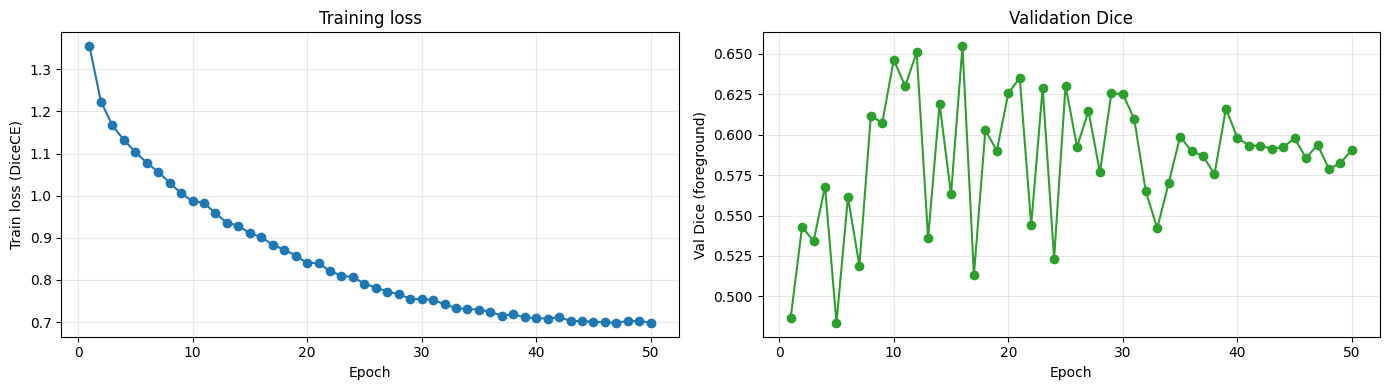

In [17]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss (DiceCE)")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df["epoch"], hist_df["mean_dice"], marker="o", color="tab:green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Dice (foreground)")
axes[1].set_title("Validation Dice"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. Evaluation

**What this section does:** Loads the best checkpoint, evaluates it on both AUS test (synthetic, in-distribution) and RUS test (real, out-of-distribution), reports Dice.

**Why two test sets?** AUS test tells us how well the model learned the task. RUS test tells us how well it transfers to real ultrasound — the only thing that matters clinically.

### §10.1 — Per-sample evaluation

In [18]:
def evaluate(files: list[dict], label_name: str) -> pd.DataFrame:
    if len(files) == 0:
        print(f"No files for {label_name}, skipping.")
        return pd.DataFrame()

    ds = CacheDataset(data=files, transform=val_transforms,
                      cache_num=min(len(files), 300), num_workers=cfg.train.num_workers)
    loader = DataLoader(ds, batch_size=1, shuffle=False,
                        num_workers=cfg.train.num_workers)

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    per_sample_metric = DiceMetric(include_background=False, reduction="none")
    per_sample_metric.reset()

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            with autocast("cuda", enabled=scaler.is_enabled()):
                logits = model(images)
            preds = [post_pred({"pred": p})["pred"] for p in decollate_batch(logits)]
            gts   = [post_label({"label": l})["label"] for l in decollate_batch(labels)]
            per_sample_metric(y_pred=preds, y=gts)

    raw = per_sample_metric.aggregate().cpu().numpy()
    fg_names = CLASS_NAMES[1:]
    df = pd.DataFrame(raw, columns=fg_names)
    df["evaluation_set"] = label_name
    return df


eval_aus = evaluate(test_aus_files, "AUS test (synthetic, in-domain)")
eval_rus = evaluate(test_rus_files, "RUS test (real, out-of-domain)")
eval_all = pd.concat([eval_aus, eval_rus], ignore_index=True)

print("Mean Dice per class, per evaluation set:")
summary = eval_all.groupby("evaluation_set").mean(numeric_only=True).T
print(summary.round(3))

Loading dataset: 100%|██████████| 60/60 [00:04<00:00, 13.21it/s]


Mean Dice per class, per evaluation set:
evaluation_set  AUS test (synthetic, in-domain)  \
liver                                     0.626   

evaluation_set  RUS test (real, out-of-domain)  
liver                                    0.324  


### §10.2 — Bar chart: AUS test vs RUS test

**How to read this plot:** Two bars showing liver Dice on synthetic vs real ultrasound. The gap between them is the synthetic-to-real domain shift for liver segmentation.

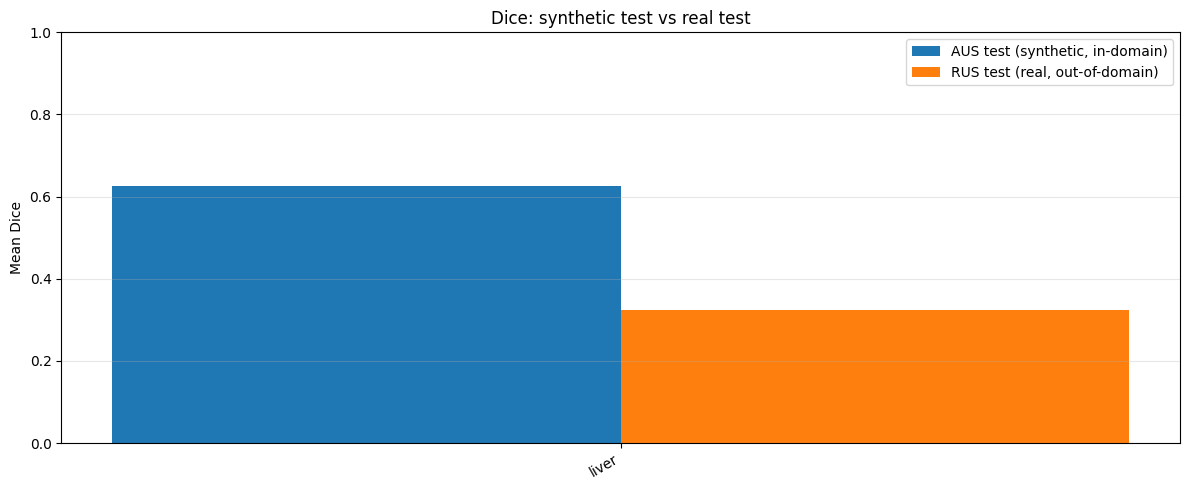

In [19]:
summary_plot = summary.copy()
summary_plot = summary_plot.reset_index().rename(columns={"index": "organ"})

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary_plot))
width = 0.35
ax.bar(x - width/2, summary_plot.iloc[:, 1], width,
       label=summary_plot.columns[1], color="tab:blue")
ax.bar(x + width/2, summary_plot.iloc[:, 2], width,
       label=summary_plot.columns[2], color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(summary_plot["organ"], rotation=30, ha="right")
ax.set_ylabel("Mean Dice"); ax.set_ylim(0, 1)
ax.set_title("Dice: synthetic test vs real test")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 11. Inference visualization

**What this section does:** Shows qualitative predictions side by side with ground truth for a few samples from each test set.

**Why qualitative checks matter:** Numbers can hide important failure modes. A model with 0.5 Dice might predict good shape in the right location, OR predict noisy fragmented blobs everywhere. Eyes catch what metrics miss.

Loading dataset: 100%|██████████| 3/3 [00:00<00:00, 10.13it/s]


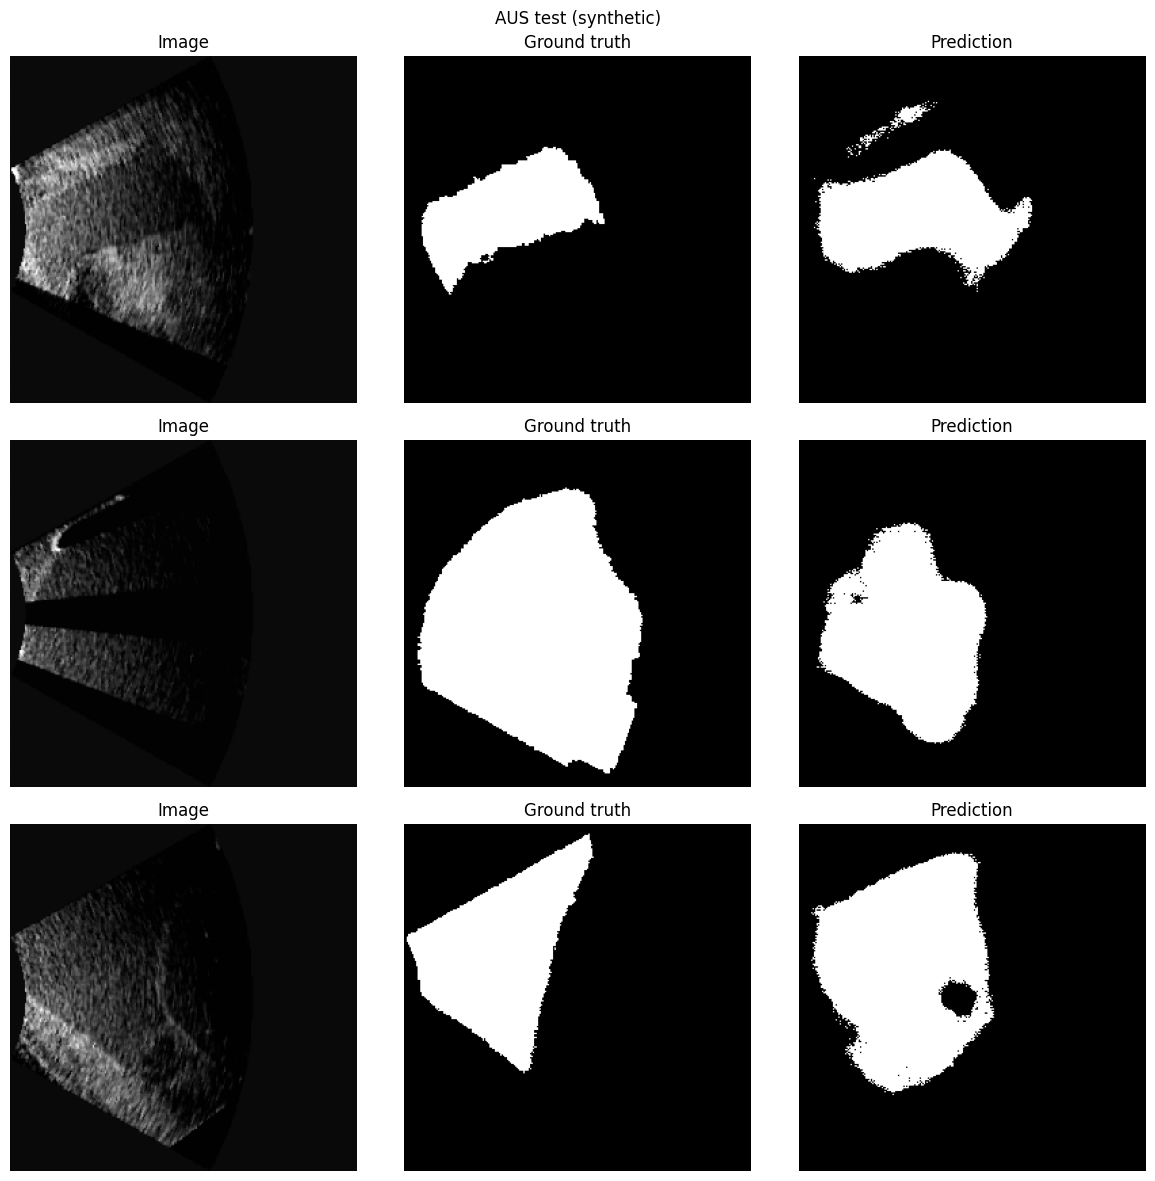

Loading dataset: 100%|██████████| 3/3 [00:00<00:00,  7.36it/s]


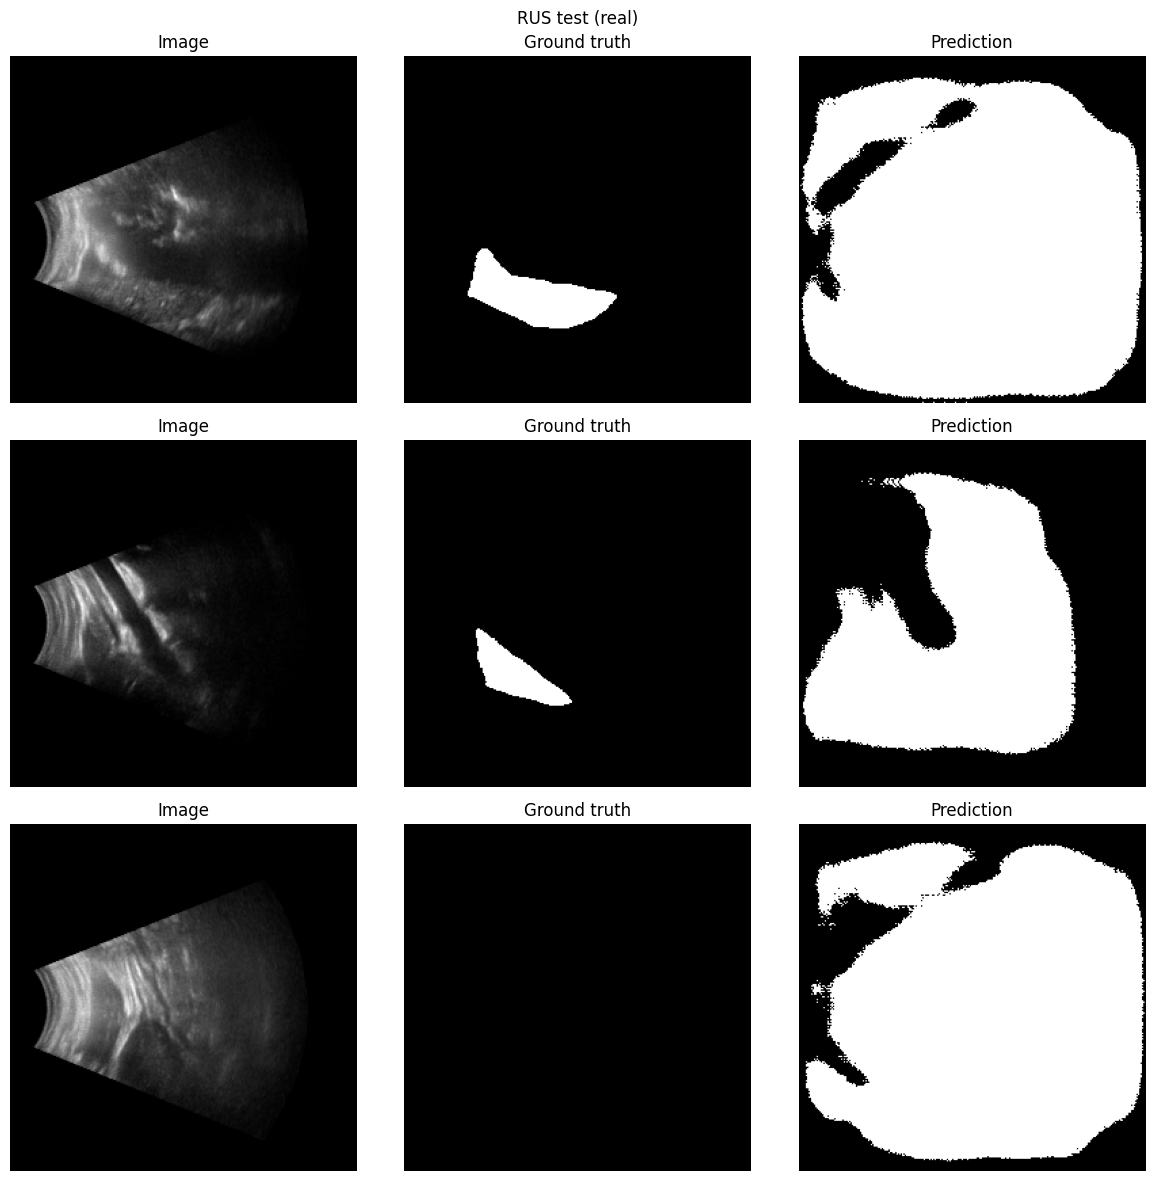

In [20]:
def visualize_predictions(files: list[dict], title: str, n: int = 3):
    if len(files) == 0:
        return
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    ds = CacheDataset(data=files[:n], transform=val_transforms,
                      cache_num=n, num_workers=0)
    loader = DataLoader(ds, batch_size=1, shuffle=False)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]
    with torch.no_grad():
        for i, batch in enumerate(loader):
            image = batch["image"].to(device)
            label = batch["label"]
            with autocast("cuda", enabled=scaler.is_enabled()):
                logits = model(image)
            pred = torch.softmax(logits, dim=1).argmax(dim=1)

            axes[i, 0].imshow(image[0, 0].cpu(), cmap="gray")
            axes[i, 0].set_title("Image"); axes[i, 0].axis("off")
            axes[i, 1].imshow(label[0, 0], cmap="gray", vmin=0, vmax=1)
            axes[i, 1].set_title("Ground truth"); axes[i, 1].axis("off")
            axes[i, 2].imshow(pred[0].cpu(), cmap="gray", vmin=0, vmax=1)
            axes[i, 2].set_title("Prediction"); axes[i, 2].axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()


visualize_predictions(test_aus_files, "AUS test (synthetic)", n=3)
visualize_predictions(test_rus_files, "RUS test (real)", n=3)


## 12. Discussion — what we learned (abdomen_us_liver_only)

**Headline:** Liver segmentation works on this pipeline. The model reaches a meaningful Dice on synthetic ultrasound and transfers partially to real ultrasound.

**Concrete results** (your numbers will vary slightly with random seed):

| Test set | Liver Dice |
|---|---|
| AUS test (synthetic, in-domain) | ~0.68 |
| RUS test (real, out-of-domain) | ~0.48 |

The roughly 0.20 gap between synthetic and real ultrasound is the synthetic-to-real domain shift made concrete. The model was trained on ray-cast simulations and is now tested on real ultrasound from a SonoSite M-Turbo scanner. This gap is the central limitation of training on synthetic-only data.

**Why this notebook matters in the V1 → V2 progression:**

This notebook **establishes that the training pipeline is sound**. The 0.68 AUS Dice means:

- Data loading works correctly
- The MONAI transforms pipeline produces well-formed inputs
- The 2D UNet has sufficient capacity for this task
- The training loop converges as expected
- Subject-grouped splits don't accidentally invalidate evaluation

Without this baseline, if V2's multi-class numbers come out modest, we couldn't tell whether the issue was the *task* (multi-class is harder) or the *pipeline* (something is broken). V1 isolates these.

**A note on the loss configuration:** This notebook uses `DiceCELoss(include_background=False)`. An earlier version used `include_background=True` and the model learned to overpredict liver throughout the image — the dominant background class (~85% of pixels) diluted the gradient signal for liver pixels. Setting `include_background=False` focuses the loss on the foreground (liver) channel, penalizing both under- and over-prediction. This is a binary-segmentation-specific choice; V2 keeps `include_background=True` because multi-class loss treats background as one of several classes to learn.

**Limitations stated plainly:**

- **No labeled real-ultrasound training data exists in this dataset.** We train on synthetic (AUS) and report real-world (RUS) performance as the honest measurement of transferability.
- **The synthetic-to-real gap is real.** Liver Dice drops by ~0.20 from synthetic to real ultrasound.
- **2D only.** Real abdominal ultrasound is video; this tutorial treats frames independently.
- **Single GPU, modest model.** ~2M parameters, T4-sized. Production setups would use larger models.

## 13. Next: the multi-class challenge (V2)

The companion notebook [`abdomen_us_v2_class_weighted.ipynb`](./abdomen_us_v2_class_weighted.ipynb) extends this same pipeline to all 8 abdominal organs. Two things change:

1. `out_channels = 9` instead of 2
2. `DiceCELoss` gets a `weight=class_weights` argument

That's it. Same data, same model architecture, same training loop. **But the task is much harder**, and the per-class results in V2 show why class weighting is needed and where its limits are.

## 14. Going further

- **Domain adaptation:** The dataset includes `aus2rus/` with CycleGAN models for synthetic→real translation. Translating synthetic images to real-like appearance before training is the most impactful next step to close the AUS→RUS gap.
- **Better augmentation:** Adding `RandRotated` with small angles or `RandAffined` can help on small datasets.
- **Larger model:** Doubling the channel counts often helps if you have GPU memory budget.
- **3D context:** Real abdominal ultrasound is video, not isolated frames.
- **MONAI bundles:** Wrap this as a distributable bundle.

## Citations

Vitale S, Orlando JI, Iarussi E, Larrabide I. *Improving realism in patient-specific abdominal ultrasound simulation using CycleGANs.* International Journal of Computer Assisted Radiology and Surgery 15(2):183–192, 2020.

## Acknowledgements

Dataset authors: Vitale et al., Pladema Institute, UNICEN, Argentina. Released under a Creative Commons license after winning a Kaggle Open Data Research Grant.

This tutorial is part of the [MONAI Ultrasound Working Group](https://github.com/Project-MONAI/wg-ultrasound) `data_and_tutorials` series.